## What is Gradient Boosting?

**Gradient Boosting** is an ensemble machine learning technique that builds models sequentially. Each new model attempts to correct the errors made by the previous models.

Instead of building one strong model directly, Gradient Boosting combines many **weak learners (usually decision trees)** into a powerful predictive model.


## Type of ML Problem

This notebook demonstrates a **Supervised Machine Learning Classification Problem**.

Goal:
Predict class labels based on input features.


## Real-World Applications

Gradient Boosting is widely used in industry for:

* Fraud Detection
* Credit Risk Scoring
* Medical Diagnosis
* Customer Churn Prediction
* Recommendation Systems
* Click-Through Rate Prediction


## Why Gradient Boosting is Useful

Advantages:

* High predictive performance
* Handles non-linear relationships
* Works well with tabular data
* Captures complex feature interactions

**Project Setup**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

**Importing Libraries**

In [2]:
from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import shap
import joblib

**Load dataset**

We will use the Breast Cancer Dataset from sklearn.

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [4]:
print("Shape:", X.shape)
X.head()

Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Data Quality Checks**

In [5]:
def data_quality_report(df):
    
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isnull().sum(),
        "missing_%": (df.isnull().sum()/len(df))*100,
        "unique": df.nunique()
    })
    
    return report

data_quality_report(X)

,dtype,missing,missing_%,unique
mean radius,float64,0,0.0,456
mean texture,float64,0,0.0,479
mean perimeter,float64,0,0.0,522
mean area,float64,0,0.0,539
mean smoothness,float64,0,0.0,474
mean compactness,float64,0,0.0,537
mean concavity,float64,0,0.0,537
mean concave points,float64,0,0.0,542
mean symmetry,float64,0,0.0,432
mean fractal dimension,float64,0,0.0,499


**Exploratory Data Analysis**

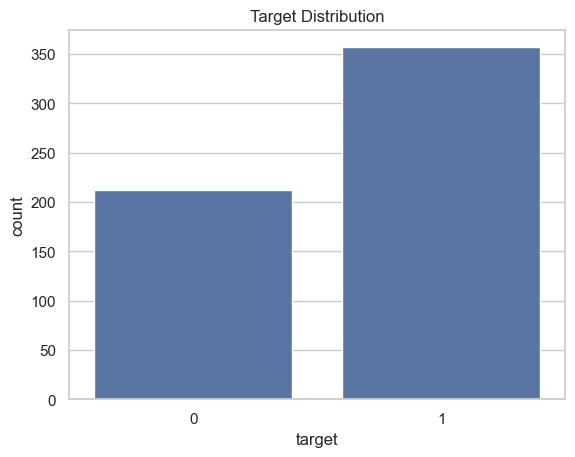

In [6]:
# Target Distribution
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

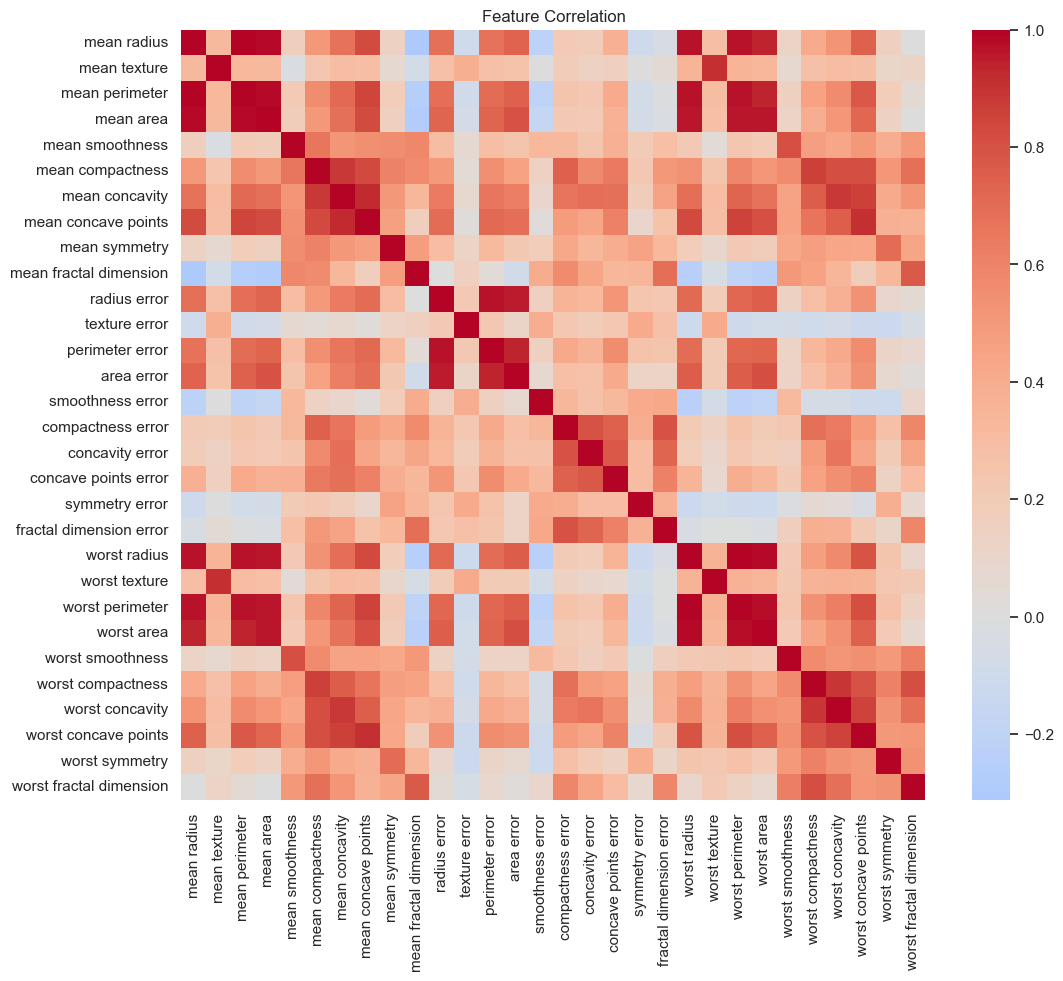

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation")
plt.show()


**Feature Engineering**

In [8]:
X["area_perimeter_ratio"] = X["mean area"] / X["mean perimeter"]

**Train Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Preprocessing Pipeline**

Professional pipelines separate numeric and categorical features

In [10]:

numeric_features = X.columns

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [11]:
# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features)
    ]
)

**Machine Learning Pipeline**

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features)
    ]
)

In [13]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

**Hyperparameter Tuning**

In [14]:
param_grid = {

    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0]

}

In [15]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'peri...
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'area_perimeter_ratio'],
      dtype='object'))])),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.8, 1.0]},
             scoring='roc_auc')

**Best Parameters and scores**

In [16]:
grid_search.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 5,
 'model__n_estimators': 300,
 'model__subsample': 0.8}

In [17]:
best_model = grid_search.best_estimator_

**Cross Validation**

In [18]:
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("CV Score Mean:", cv_scores.mean())

CV Score Mean: 0.991640866873065


**Model Evaluation**

In [19]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [20]:
# Classification metrics
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1:", f1_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1: 0.9659863945578231
ROC-AUC: 0.9933862433862434


In [21]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**ROC Curve**

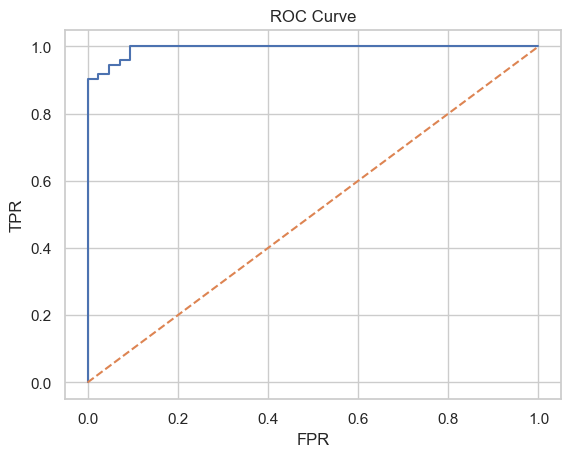

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("ROC Curve")

plt.show()

**Feature Importance**

In [23]:
model = best_model.named_steps["model"]

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

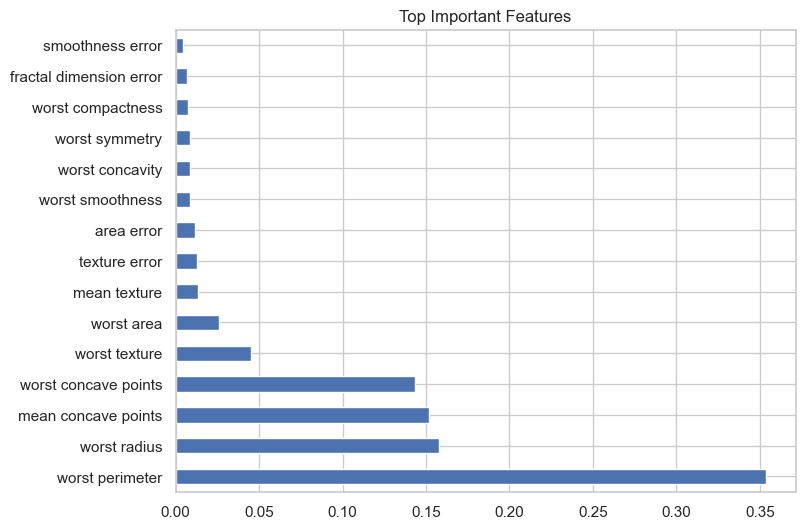

In [24]:
# Top Features
importance.head(15).plot(kind="barh", figsize=(8,6))
plt.title("Top Important Features")
plt.show()

**Model Explainability**

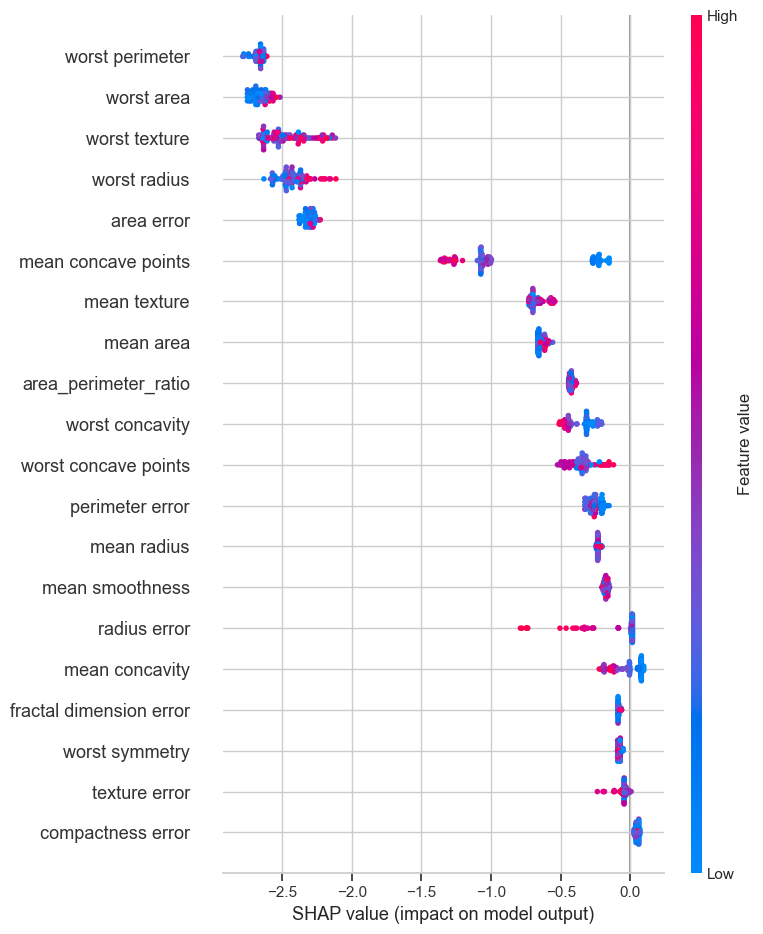

In [25]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

**Learning Curve**

In [26]:
from sklearn.model_selection import learning_curve

In [27]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5
)

**Final Model Insights**


Example conclusions:

Key insights:

1. Gradient Boosting achieved strong classification performance.
2. Important features include:

   * mean radius
   * mean area
   * mean perimeter
3. The model shows good balance between precision and recall.
4. Cross-validation confirms stable performance.

Possible improvements:

* Use **XGBoost**
* Use **LightGBM**
* Apply **feature selection**
* Use **Optuna for hyperparameter optimization**

**Saving the Model**

In [28]:
joblib.dump(best_model, "random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Gradient Boosting — Theory


### 1. Algorithm Overview

Gradient Boosting works by:

1. Start with a simple model
2. Compute errors (residuals)
3. Train a new model to predict residuals
4. Add this new model to the ensemble
5. Repeat many times

Final prediction:

Prediction = Sum of all trees.


### 2. Mathematical Intuition

Gradient Boosting minimizes a **loss function** using gradient descent.

Model update:

NewModel = OldModel + learning_rate × Tree

Where the tree fits the **negative gradient of the loss function**.


### 3. When to Use This Model

Gradient Boosting performs best when:

* Tabular structured data
* Non-linear relationships
* Medium-size datasets
* High accuracy required

Used widely in **Kaggle competitions**.



### 4. Advantages

Strengths:

* Very high predictive accuracy
* Handles complex patterns
* Robust to overfitting with tuning
* Works with different loss functions



### 5. Disadvantages

Limitations:

* Slower training
* Sensitive to hyperparameters
* Can overfit if too many trees
* Harder to parallelize
